# S&P 500 Intraday Market Exploration

This notebook explores how price movement developed across current S&P 500 constituents during a recent intraday-data window.

Each trading day is decomposed into:

1. **Overnight:** previous close to the regular-session open  
2. **Opening period:** 09:30–10:00 New York time  
3. **Rest of day:** 10:00–regular-session close  

The study examines where movement occurred, whether unusually large opening moves persisted or reversed, whether positive and negative opening moves behaved differently, and whether the effect remained after removing the cross-sectional market move.

This is an **exploratory market study**. It does not define or evaluate a trading strategy.

In [1]:
import datetime as dt
from datetime import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf


In [2]:
snp500_instruments = pd.read_csv("/Users/pankajti/dev/git/event-driven-narrative-trading/icaif_2026/data/snp_500_instruments.csv")

In [3]:
snp500_instruments.head()

,id,con_id,symbol,market,exchange,primary_exchange,currency,country,sector,industry,sub_industry,long_name,is_active,updated_at
0,8,265768,ADBE,US,SMART,NASDAQ,USD,NaN,Technology,Software,Electronic Forms,ADOBE INC,True,2026-06-13 22:32:43.945
1,9,4157,ADI,US,SMART,NASDAQ,USD,NaN,Technology,Semiconductors,Electronic Compo-Semicon,ANALOG DEVICES INC,True,2026-06-13 22:32:43.945
2,10,4165,ADM,US,SMART,NYSE,USD,NaN,"Consumer, Non-cyclical",Agriculture,Agricultural Operations,ARCHER-DANIELS-MIDLAND CO,True,2026-06-13 22:32:43.945
3,11,4661,ADP,US,SMART,NASDAQ,USD,NaN,"Consumer, Non-cyclical",Commercial Services,Commercial Services,AUTOMATIC DATA PROCESSING,True,2026-06-13 22:32:43.945
4,12,265681,ADSK,US,SMART,NASDAQ,USD,NaN,Technology,Software,Computer Aided Design,AUTODESK INC,True,2026-06-13 22:32:43.945


In [4]:
symbols = snp500_instruments.symbol.to_list()
num_sym = 550

In [5]:
top_symbols = symbols [:num_sym]

In [6]:
symbol_map = {
    "BRK B": "BRK-B",
    "BF B": "BF-B",
}

download_symbols = [
    symbol_map.get(symbol, symbol)
    for symbol in top_symbols
]

In [7]:
#we can't download more than 60 days data from yfinance so i added 55 days data download to be safe
end_date = dt.datetime.now()-dt.timedelta(1)
start_date = end_date -dt.timedelta(55)

In [8]:
start_date = dt.datetime.strftime(start_date,"%Y-%m-%d") #"2026-06-01"
end_date = dt.datetime.strftime(end_date,"%Y-%m-%d") #"2026-06-01"


In [9]:
hist_data = yf.Tickers(download_symbols).history(start =start_date, end=end_date, interval = '30m')

[*********************100%***********************]  516 of 516 completed


## Method

`hist_data` is treated as intraday price history with a timezone-aware datetime index and multi-level price columns.

For every symbol and trading date, the notebook extracts:

- previous regular-session close;
- 09:30 opening price;
- approximately 10:00 price;
- regular-session close;
- first-30-minute high and low for descriptive volatility checks.

Returns are calculated as additive log returns:

- `overnight_return = log(open / previous_close)`
- `opening_return = log(price_10 / open)`
- `post_opening_return = log(close / price_10)`
- `full_day_return = log(close / previous_close)`

The main exploratory event is an **extreme opening move**, defined as a stock whose absolute first-30-minute return lies in the largest 20% of stocks on that date.

A positive direction-adjusted rest-of-day return indicates persistence in the opening direction; a negative value indicates reversal.

In [10]:

bars = hist_data.copy()

# Convert to exchange-local time.
if bars.index.tz is None:
    bars.index = bars.index.tz_localize("UTC")

bars.index = bars.index.tz_convert("America/New_York")

# Extract one price field at a time.
# The resulting columns should be ticker symbols only.
open_px = bars.xs("Open", axis=1, level="Price")
high_px = bars.xs("High", axis=1, level="Price")
low_px = bars.xs("Low", axis=1, level="Price")
close_px = bars.xs("Close", axis=1, level="Price")

for frame in [open_px, high_px, low_px, close_px]:
    frame.columns.name = "symbol"

times = bars.index.time

first_30_mask = (
    (times >= time(9, 30))
    & (times < time(10, 0))
)

regular_mask = (
    (times >= time(9, 30))
    & (times < time(16, 0))
)



In [11]:
symbol_has_data = close_px.notna().any(axis=0)

successful_symbols = symbol_has_data[
    symbol_has_data
].index.tolist()

failed_symbols = symbol_has_data[
    ~symbol_has_data
].index.tolist()

print("Successful symbols:", len(successful_symbols))
print("Failed symbols:", failed_symbols)

Successful symbols: 516
Failed symbols: []


In [12]:
def group_by_local_date(frame, mask):
    selected = frame.loc[mask]
    date_index = pd.Index(selected.index.date, name="date")
    return selected.groupby(date_index)

daily_open = group_by_local_date(
    open_px, first_30_mask
).first()

daily_price_10 = group_by_local_date(
    close_px, first_30_mask
).last()

daily_orh = group_by_local_date(
    high_px, first_30_mask
).max()

daily_orl = group_by_local_date(
    low_px, first_30_mask
).min()

daily_close = group_by_local_date(
    close_px, regular_mask
).last()

# Do not silently carry an old close across a missing trading day.
daily_prev_close = daily_close.shift(1)
 

In [13]:
daily_prev_close

symbol,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZS,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-11,115.610001,293.279999,201.479996,141.470001,84.300003,93.809998,180.500000,253.100006,416.510010,77.650002,...,102.410004,79.370003,144.399994,113.739998,74.860001,151.940002,82.330002,226.029999,152.149994,82.820000
2026-05-12,111.500000,292.739990,202.820007,137.110001,82.570000,93.830002,172.419998,246.139999,422.679993,79.830002,...,99.360001,80.574997,149.679993,112.050003,73.169998,150.330002,79.584999,216.979996,148.869995,76.660004
2026-05-13,112.930000,294.869995,207.949997,135.460007,84.375000,94.330002,169.800003,240.869995,419.649994,80.745003,...,97.260002,79.879997,150.660004,111.555000,72.160004,152.919998,83.400002,241.779999,146.130005,76.949997
2026-05-14,112.730003,298.880005,208.539993,132.970001,83.820000,93.309998,159.570007,236.080002,432.380005,82.879997,...,96.199997,79.900002,151.589996,109.010002,69.790001,149.869995,82.739998,246.949997,152.429993,74.320000
2026-05-15,113.269997,298.165009,210.770004,133.669998,84.894997,93.470001,163.960007,237.029999,426.750000,81.410004,...,95.419998,80.019997,152.774994,109.419998,71.529999,150.610001,82.650002,258.170013,153.770004,75.489998
2026-05-18,111.699997,300.220001,210.369995,132.880005,84.480003,93.930000,168.820007,247.585007,417.309998,80.410004,...,95.419998,77.870003,157.929993,108.139999,70.355003,150.020004,83.699997,259.420013,161.050003,74.239998
2026-05-19,112.129997,297.899994,209.460007,134.289993,87.875000,95.879997,177.529999,255.660004,418.579987,80.900002,...,95.500000,78.089996,160.479996,108.290001,70.620003,152.320007,85.129997,260.040009,174.669998,77.720001
2026-05-20,110.519997,298.980011,213.919998,131.169998,88.834999,96.430000,176.740005,254.990005,414.779999,79.389999,...,94.839996,79.750000,162.619995,106.339996,69.190002,152.229996,86.089996,247.029999,175.360001,78.925003


In [14]:
assert daily_open.columns.equals(daily_price_10.columns)
assert daily_open.columns.equals(daily_close.columns)
assert daily_open.index.equals(daily_price_10.index)

In [15]:
overnight_return = np.log(
    daily_open / daily_prev_close
)

opening_return = np.log(
    daily_price_10 / daily_open
)

post_opening_return = np.log(
    daily_close / daily_price_10
)

full_day_return_direct = np.log(
    daily_close / daily_prev_close
)

In [16]:
component_return = (
    overnight_return
    + opening_return
    + post_opening_return
)

decomposition_error = (
    full_day_return_direct - component_return
)

max_error = np.nanmax(
    np.abs(decomposition_error.to_numpy())
)

print("Maximum decomposition error:", max_error)

Maximum decomposition error: 3.95516952522712e-16


In [17]:
quality = {
    "requested_symbols": len(top_symbols),
    "downloaded_symbols": len(close_px.columns),
    "number_of_dates": len(daily_close),
    "first_date": daily_close.index.min(),
    "last_date": daily_close.index.max(),
    "valid_open_values": int(daily_open.notna().sum().sum()),
    "valid_close_values": int(daily_close.notna().sum().sum()),
    "valid_stock_days": int(
        (
            daily_open.notna()
            & daily_price_10.notna()
            & daily_close.notna()
            & daily_prev_close.notna()
        ).sum().sum()
    ),
}

pd.Series(quality)

requested_symbols            516
downloaded_symbols           516
number_of_dates               37
first_date            2026-05-08
last_date             2026-07-01
valid_open_values          19061
valid_close_values         19061
valid_stock_days           18545
dtype: object

In [18]:
assert not daily_open.columns.duplicated().any()
assert not daily_open.index.duplicated().any()

#assert (daily_open > 0).all().all()
#assert (daily_price_10 > 0).all().all()
#assert (daily_close > 0).all().all()

#assert (daily_orh >= daily_orl).all().all()

In [19]:

missing_open_count = daily_open.isna().sum().sum()

nonpositive_open = (
    daily_open.notna()
    & daily_open.le(0)
)

print("Missing opening prices:", missing_open_count)
print("Non-positive opening prices:", nonpositive_open.sum().sum())

Missing opening prices: 31
Non-positive opening prices: 0


In [20]:
missing_by_symbol = (
    daily_open.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_by_symbol[
        missing_by_symbol > 0
    ].head(30)
)

symbol
FDXF    15
BNY     10
SATS     6
dtype: int64

In [21]:
bad_open_locations = (
    daily_open
    .where(nonpositive_open)
    .stack()
)

display(bad_open_locations)

Series([], dtype: float64)

In [22]:
assert not daily_open.le(0).any().any()
assert not daily_price_10.le(0).any().any()
assert not daily_close.le(0).any().any()

In [23]:
frames = {
    "open": daily_open,
    "price_10": daily_price_10,
    "orh": daily_orh,
    "orl": daily_orl,
    "close": daily_close,
    "prev_close": daily_prev_close,
}

quality_rows = []

for name, frame in frames.items():
    stacked = frame.stack()

    quality_rows.append({
        "field": name,
        "total_cells": frame.size,
        "valid_cells": int(frame.notna().sum().sum()),
        "missing_cells": int(frame.isna().sum().sum()),
        "nonpositive_cells": int(stacked.le(0).sum()),
        "minimum_valid_value": (
            float(stacked.min())
            if not stacked.empty
            else np.nan
        ),
    })

quality_report = pd.DataFrame(quality_rows)

display(quality_report)

,field,total_cells,valid_cells,missing_cells,nonpositive_cells,minimum_valid_value
0,open,19092,19061,31,0,9.36
1,price_10,19092,19061,31,0,9.59
2,orh,19092,19061,31,0,9.62
3,orl,19092,19061,31,0,9.35
4,close,19092,19061,31,0,9.43
5,prev_close,19092,18546,546,0,9.43


In [24]:

valid_range = (
    daily_orh.notna()
    & daily_orl.notna()
)

invalid_range = (
    valid_range
    & daily_orh.lt(daily_orl)
)

assert not invalid_range.any().any(), (
    "Some ORH values are below ORL"
)

In [25]:
valid_orb = (
    daily_open.notna()
    & daily_price_10.notna()
    & daily_orh.notna()
    & daily_orl.notna()
)

bad_open = valid_orb & (
    daily_open.lt(daily_orl)
    | daily_open.gt(daily_orh)
)

bad_10 = valid_orb & (
    daily_price_10.lt(daily_orl)
    | daily_price_10.gt(daily_orh)
)

print(
    "Open outside OR range:",
    int(bad_open.sum().sum())
)

print(
    "10:00 price outside OR range:",
    int(bad_10.sum().sum())
)

assert not bad_open.any().any()
assert not bad_10.any().any()

Open outside OR range: 0
10:00 price outside OR range: 0


In [26]:
intraday_valid = (
    daily_open.gt(0)
    & daily_price_10.gt(0)
    & daily_orh.gt(0)
    & daily_orl.gt(0)
    & daily_close.gt(0)
)

overnight_valid = (
    intraday_valid
    & daily_prev_close.gt(0)
)

In [27]:
opening_return = np.log(
    daily_price_10 / daily_open
).where(intraday_valid)

post_opening_return = np.log(
    daily_close / daily_price_10
).where(intraday_valid)

overnight_return = np.log(
    daily_open / daily_prev_close
).where(overnight_valid)

full_day_return = np.log(
    daily_close / daily_prev_close
).where(overnight_valid)

In [28]:
total_stock_days = intraday_valid.size

usable_intraday_days = int(
    intraday_valid.sum().sum()
)

usable_overnight_days = int(
    overnight_valid.sum().sum()
)

print("Total stock-days:", total_stock_days)

print(
    "Usable intraday stock-days:",
    usable_intraday_days,
    f"({usable_intraday_days / total_stock_days:.2%})",
)

print(
    "Usable overnight/full-day stock-days:",
    usable_overnight_days,
    f"({usable_overnight_days / total_stock_days:.2%})",
)

Total stock-days: 19092
Usable intraday stock-days: 19061 (99.84%)
Usable overnight/full-day stock-days: 18545 (97.13%)


In [29]:
opening_strength = opening_return.abs()

daily_threshold = opening_strength.quantile(
    0.80, axis=1
)


In [30]:
opening_volatility = (
    opening_return
    .rolling(20, min_periods=10)
    .std()
    .shift(1)
)

opening_zscore = (
    opening_return / opening_volatility
)

 

In [31]:
strong_open_cross_sectional = (
    opening_strength.ge(
        daily_threshold,
        axis=0
    )
    & opening_return.notna()
)

strong_open_timeseries = (
    opening_zscore.abs() >= 1
)

In [32]:
valid_pattern = (
    opening_return.notna()
    & post_opening_return.notna()
)

pattern = pd.DataFrame(
    pd.NA,
    index=opening_return.index,
    columns=opening_return.columns,
    dtype="string",
)

up_open = opening_return.gt(0)
down_open = opening_return.lt(0)
up_later = post_opening_return.gt(0)
down_later = post_opening_return.lt(0)

pattern[
    valid_pattern & up_open & up_later
] = "Up continuation"

pattern[
    valid_pattern & up_open & down_later
] = "Up reversal"

pattern[
    valid_pattern & down_open & down_later
] = "Down continuation"

pattern[
    valid_pattern & down_open & up_later
] = "Down reversal"

In [33]:
continuation = (
    np.sign(opening_return)
    == np.sign(post_opening_return)
).where(valid_pattern)

In [34]:
stock_opening_excess = (
    opening_return.sub(
        opening_return.median(axis=1),
        axis=0,
    )
)

stock_post_opening_excess = (
    post_opening_return.sub(
        post_opening_return.median(axis=1),
        axis=0,
    )
)

In [35]:
stock_opening_excess

symbol,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZS,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08,-0.029711,0.018217,0.001448,0.030140,-0.013085,-0.000681,-0.017467,-0.021584,0.004323,0.002234,...,-0.024923,0.003527,-3.546235e-03,0.001239,-0.024592,-0.009043,-0.013763,-0.009909,-0.016118,-0.035343
2026-05-11,-0.013440,-0.002158,0.014691,-0.001628,-0.006748,0.004580,-0.023339,-0.002086,-0.003888,0.003034,...,-0.009781,0.007334,6.509115e-03,-0.002161,-0.022942,-0.004032,-0.003361,-0.005539,-0.002393,-0.015896
2026-05-12,0.010082,0.010589,0.011278,-0.009809,0.012492,0.005627,0.002791,-0.009559,-0.004327,-0.000174,...,0.003730,-0.003326,1.054509e-03,0.006136,0.002962,0.005466,0.009240,0.003222,-0.008920,-0.002118
2026-05-13,0.007133,0.007574,0.007949,-0.006001,0.007601,0.013788,-0.028061,-0.009458,0.010199,-0.002473,...,-0.014608,0.007490,9.066697e-03,-0.004248,-0.032071,0.001038,0.006778,-0.034462,0.007911,0.000847
2026-05-14,0.017831,-0.009004,0.010100,-0.001919,0.005764,0.003701,0.003999,-0.021715,-0.008755,-0.008140,...,-0.001592,0.005264,5.237833e-03,-0.002321,-0.000510,0.007148,-0.003884,-0.002912,-0.043177,0.009157
2026-05-15,0.005509,0.003826,-0.000209,-0.004085,-0.003439,0.007838,-0.001287,0.002007,0.003354,-0.001701,...,-0.006885,-0.008305,1.162313e-02,0.008384,0.008976,0.010025,0.006480,-0.011893,-0.008077,0.004739
2026-05-18,0.003221,-0.016416,-0.014205,0.016623,0.017368,0.012278,0.018350,0.002587,-0.018839,-0.017490,...,0.001879,-0.004210,-1.759482e-02,-0.008466,0.015613,0.000492,0.011264,-0.008454,0.038211,0.025144
2026-05-19,0.007269,0.002801,0.010455,0.008364,0.003939,-0.000815,0.017601,0.002621,0.008554,-0.022637,...,0.000025,0.011196,-6.579621e-03,-0.004217,0.009430,-0.000735,0.002821,-0.012761,0.011852,-0.002998
2026-05-20,-0.009350,0.005299,-0.000298,-0.007193,-0.001927,-0.000962,-0.001529,-0.008462,0.029453,-0.008954,...,-0.007551,-0.001212,3.597978e-03,-0.002433,0.002888,-0.000864,-0.005986,-0.013993,0.010739,0.007947


In [36]:
valid_strong_event = (
    strong_open_cross_sectional
    & opening_return.notna()
    & post_opening_return.notna()
)

strong_continuation = (
    np.sign(opening_return)
    == np.sign(post_opening_return)
).where(valid_strong_event)

continuation_rate = (
    strong_continuation
    .stack()
    .mean()
)

number_of_events = (
    valid_strong_event
    .sum()
    .sum()
)

print("Strong-opening events:", number_of_events)
print(
    "Continuation rate:",
    f"{continuation_rate:.2%}"
)

Strong-opening events: 3827
Continuation rate: 46.49%


In [37]:
up_strong = (
    valid_strong_event
    & opening_return.gt(0)
)

down_strong = (
    valid_strong_event
    & opening_return.lt(0)
)

up_continuation_rate = (
    post_opening_return
    .gt(0)
    .where(up_strong)
    .stack()
    .mean()
)

down_continuation_rate = (
    post_opening_return
    .lt(0)
    .where(down_strong)
    .stack()
    .mean()
)

print(
    "Up-opening continuation:",
    f"{up_continuation_rate:.2%}"
)

print(
    "Down-opening continuation:",
    f"{down_continuation_rate:.2%}"
)

Up-opening continuation: 46.66%
Down-opening continuation: 46.29%


In [38]:
directional_post_return = (
    np.sign(opening_return)
    * post_opening_return
).where(valid_strong_event)

directional_values = (
    directional_post_return
    .stack()
)

print(
    "Median direction-adjusted post-open return:",
    f"{directional_values.median():.4%}"
)

print(
    "Mean direction-adjusted post-open return:",
    f"{directional_values.mean():.4%}"
)

print(
    "25th percentile:",
    f"{directional_values.quantile(0.25):.4%}"
)

print(
    "75th percentile:",
    f"{directional_values.quantile(0.75):.4%}"
)

Median direction-adjusted post-open return: -0.1407%
Mean direction-adjusted post-open return: -0.1833%
25th percentile: -1.3217%
75th percentile: 1.0500%


In [39]:
pattern_long = (
    pattern
    .where(valid_strong_event)
    .stack()
    .rename("pattern")
    .reset_index()
)

pattern_summary = (
    pattern_long["pattern"]
    .value_counts()
    .rename_axis("pattern")
    .to_frame("count")
)

pattern_summary["percentage"] = (
    pattern_summary["count"]
    / pattern_summary["count"].sum()
)

display(pattern_summary)

,count,percentage
pattern,,
Up reversal,1091,0.285527
Up continuation,956,0.250196
Down reversal,951,0.248888
Down continuation,823,0.215389


# Exploratory summaries and visualizations

The charts below summarize the market structure without introducing breakout, entry, stop-loss, or profitability assumptions.

In [40]:
analysis_start = pd.Timestamp(daily_close.index.min())
analysis_end = pd.Timestamp(daily_close.index.max())

print(f"Analysis window: {analysis_start.date()} to {analysis_end.date()}")
print(f"Trading dates: {len(daily_close.index)}")
print(f"Symbols with data: {len(successful_symbols)}")
print(f"Usable intraday stock-days: {int(intraday_valid.sum().sum()):,}")


Analysis window: 2026-05-08 to 2026-07-01
Trading dates: 37
Symbols with data: 516
Usable intraday stock-days: 19,061


## 1. Where did price movement occur?

Mean absolute return measures the typical magnitude of movement regardless of direction. It is more useful than the signed mean when comparing how much price discovery occurred in each part of the day.

In [41]:
period_series = {
    "Overnight": overnight_return.stack(),
    "First 30 minutes": opening_return.stack(),
    "Rest of day": post_opening_return.stack(),
    "Full day": full_day_return.stack(),
}

period_summary = pd.DataFrame(
    {
        period: {
            "observations": values.count(),
            "mean_return": values.mean(),
            "median_return": values.median(),
            "mean_absolute_return": values.abs().mean(),
            "median_absolute_return": values.abs().median(),
            "volatility": values.std(),
            "q25": values.quantile(0.25),
            "q75": values.quantile(0.75),
        }
        for period, values in period_series.items()
    }
).T

display(
    period_summary.style.format(
        {
            "observations": "{:,.0f}",
            "mean_return": "{:.3%}",
            "median_return": "{:.3%}",
            "mean_absolute_return": "{:.3%}",
            "median_absolute_return": "{:.3%}",
            "volatility": "{:.3%}",
            "q25": "{:.3%}",
            "q75": "{:.3%}",
        }
    )
)


,observations,mean_return,median_return,mean_absolute_return,median_absolute_return,volatility,q25,q75
Overnight,"18,545",0.071%,0.054%,0.876%,0.576%,1.480%,-0.503%,0.642%
First 30 minutes,"19,061",0.079%,0.083%,0.965%,0.685%,1.374%,-0.583%,0.772%
Rest of day,"19,061",-0.076%,-0.075%,1.199%,0.872%,1.679%,-0.969%,0.778%
Full day,"18,545",0.084%,0.082%,1.817%,1.299%,2.635%,-1.242%,1.360%


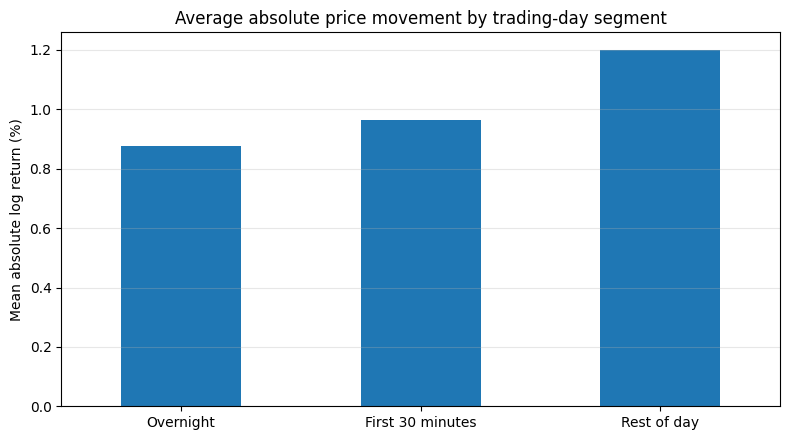

In [42]:
movement_chart = (
    period_summary.loc[
        ["Overnight", "First 30 minutes", "Rest of day"],
        "mean_absolute_return",
    ]
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
movement_chart.plot(kind="bar", ax=ax)
ax.set_title("Average absolute price movement by trading-day segment")
ax.set_xlabel("")
ax.set_ylabel("Mean absolute log return (%)")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 2. Persistence and reversal of extreme opening moves

The chart shows the four directional outcomes among stocks in the largest daily quintile of absolute first-30-minute returns.

In [43]:
flat_event = (
    valid_strong_event
    & (
        opening_return.eq(0)
        | post_opening_return.eq(0)
    )
)

pattern_with_flat = pattern.copy()
pattern_with_flat[flat_event] = "Flat or unchanged"

pattern_long_visual = (
    pattern_with_flat
    .where(valid_strong_event)
    .stack()
    .rename("pattern")
    .reset_index()
)

pattern_summary_visual = (
    pattern_long_visual["pattern"]
    .value_counts()
    .rename_axis("pattern")
    .to_frame("count")
)

pattern_summary_visual["percentage"] = (
    pattern_summary_visual["count"]
    / pattern_summary_visual["count"].sum()
)

display(
    pattern_summary_visual.style.format(
        {"count": "{:,.0f}", "percentage": "{:.2%}"}
    )
)


,count,percentage
pattern,,
Up reversal,"1,091",28.51%
Up continuation,956,24.98%
Down reversal,951,24.85%
Down continuation,823,21.51%
Flat or unchanged,6,0.16%


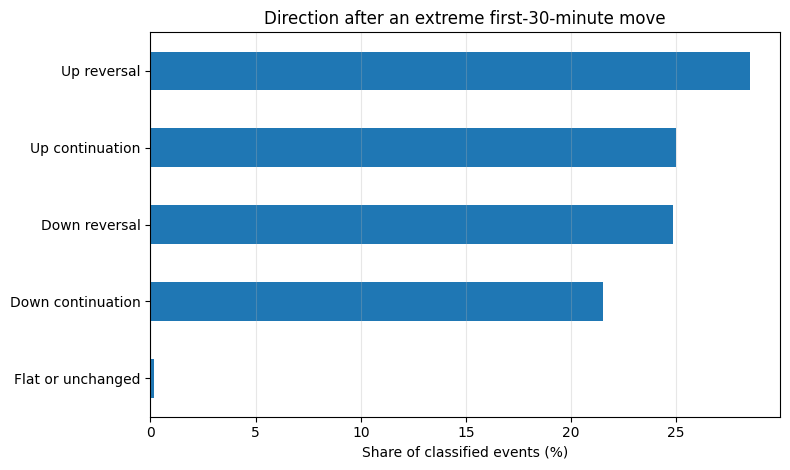

In [44]:
pattern_chart = (
    pattern_summary_visual["percentage"]
    .sort_values(ascending=True)
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 4.8))
pattern_chart.plot(kind="barh", ax=ax)
ax.set_title("Direction after an extreme first-30-minute move")
ax.set_xlabel("Share of classified events (%)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Did the result persist across trading dates?

Stock observations on the same date are correlated. Daily aggregation helps show whether the overall result was broad-based or driven by a few unusual sessions.

In [45]:
daily_summary = pd.DataFrame(
    {
        "extreme_events": valid_strong_event.sum(axis=1),
        "continuation_rate": strong_continuation.mean(axis=1),
        "mean_persistence_return": directional_post_return.mean(axis=1),
        "median_persistence_return": directional_post_return.median(axis=1),
    }
)

daily_summary.index = pd.to_datetime(daily_summary.index)

display(
    daily_summary.style.format(
        {
            "extreme_events": "{:,.0f}",
            "continuation_rate": "{:.2%}",
            "mean_persistence_return": "{:.3%}",
            "median_persistence_return": "{:.3%}",
        }
    )
)

print(
    "Days with continuation above 50%:",
    int(daily_summary["continuation_rate"].gt(0.50).sum()),
)
print(
    "Days with continuation below 50%:",
    int(daily_summary["continuation_rate"].lt(0.50).sum()),
)
print(
    "Days with negative mean persistence return:",
    int(daily_summary["mean_persistence_return"].lt(0).sum()),
)


,extreme_events,continuation_rate,mean_persistence_return,median_persistence_return
date,,,,
2026-05-08 00:00:00,103,41.75%,-0.148%,-0.295%
2026-05-11 00:00:00,103,66.99%,0.726%,0.570%
2026-05-12 00:00:00,103,33.98%,-0.627%,-0.764%
2026-05-13 00:00:00,103,33.98%,-0.558%,-0.678%
2026-05-14 00:00:00,103,50.49%,-0.363%,0.019%
2026-05-15 00:00:00,103,61.17%,0.216%,0.436%
2026-05-18 00:00:00,103,61.17%,0.283%,0.400%
2026-05-19 00:00:00,103,43.69%,-0.483%,-0.434%
2026-05-20 00:00:00,103,47.57%,-0.091%,-0.141%


Days with continuation above 50%: 13
Days with continuation below 50%: 24
Days with negative mean persistence return: 21


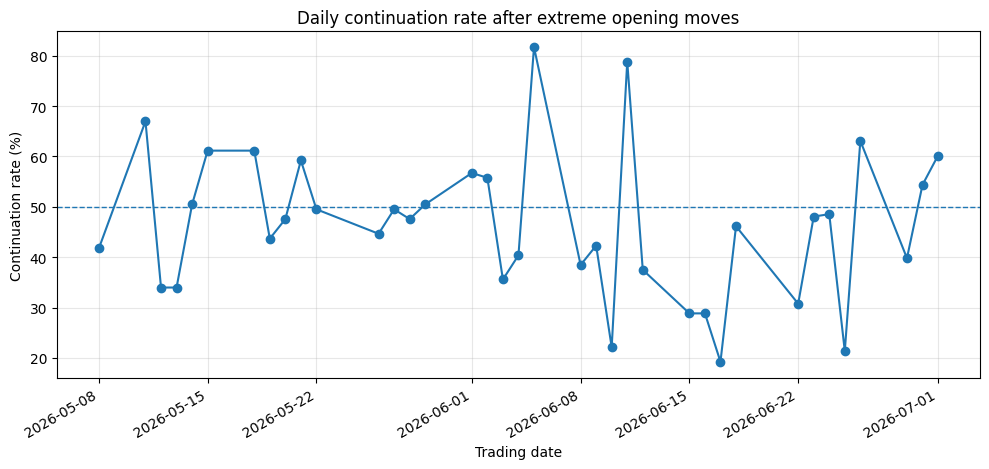

In [46]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(
    daily_summary.index,
    daily_summary["continuation_rate"].mul(100),
    marker="o",
)
ax.axhline(50, linestyle="--", linewidth=1)
ax.set_title("Daily continuation rate after extreme opening moves")
ax.set_xlabel("Trading date")
ax.set_ylabel("Continuation rate (%)")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


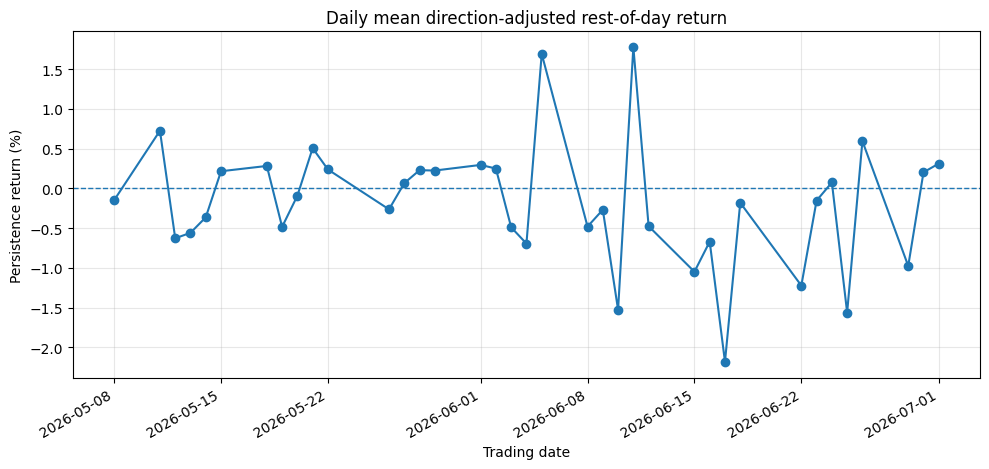

In [47]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(
    daily_summary.index,
    daily_summary["mean_persistence_return"].mul(100),
    marker="o",
)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Daily mean direction-adjusted rest-of-day return")
ax.set_xlabel("Trading date")
ax.set_ylabel("Persistence return (%)")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 4. Relationship between opening and rest-of-day movement

A downward-sloping relationship is consistent with reversal; an upward-sloping relationship is consistent with persistence. The chart is descriptive and does not establish causality.

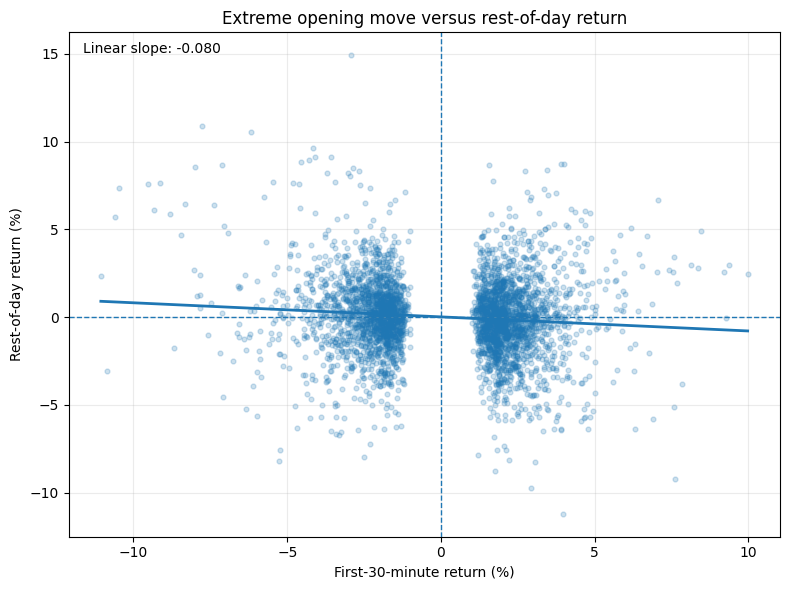

In [48]:
scatter_data = pd.DataFrame(
    {
        "opening_return": opening_return.where(valid_strong_event).stack(),
        "rest_of_day_return": post_opening_return.where(valid_strong_event).stack(),
    }
).dropna()

x = scatter_data["opening_return"].mul(100)
y = scatter_data["rest_of_day_return"].mul(100)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.22, s=12)

if len(scatter_data) >= 2 and x.nunique() > 1:
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, linewidth=2)
    ax.text(
        0.02,
        0.98,
        f"Linear slope: {slope:.3f}",
        transform=ax.transAxes,
        va="top",
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Extreme opening move versus rest-of-day return")
ax.set_xlabel("First-30-minute return (%)")
ax.set_ylabel("Rest-of-day return (%)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 5. Does reversal strengthen as opening moves become more extreme?

This analysis avoids relying only on a single top-20% cutoff. Stocks are ranked into five daily quintiles by the absolute size of their first-30-minute return.

In [49]:
opening_rank_pct = opening_strength.rank(
    axis=1,
    pct=True,
    method="average",
)

opening_quintile = np.ceil(opening_rank_pct * 5).clip(1, 5)

all_persistence_return = (
    np.sign(opening_return)
    * post_opening_return
).where(valid_pattern)

quintile_data = pd.DataFrame(
    {
        "quintile": opening_quintile.stack(),
        "persistence_return": all_persistence_return.stack(),
    }
).dropna()

quintile_data["quintile"] = quintile_data["quintile"].astype(int)

quintile_summary = (
    quintile_data.groupby("quintile")["persistence_return"]
    .agg(["count", "mean", "median"])
)

display(
    quintile_summary.style.format(
        {"count": "{:,.0f}", "mean": "{:.3%}", "median": "{:.3%}"}
    )
)


,count,mean,median
quintile,,,
1,"3,801",-0.018%,-0.000%
2,"3,811",-0.020%,0.000%
3,"3,811",-0.106%,-0.094%
4,"3,811",-0.123%,-0.122%
5,"3,827",-0.183%,-0.141%


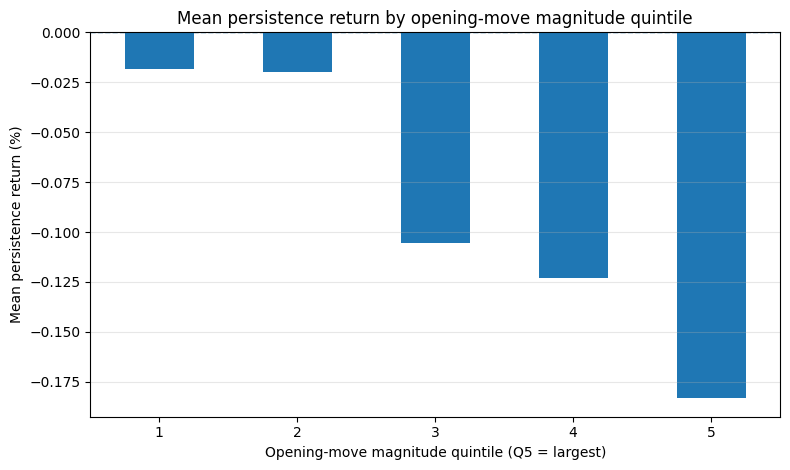

In [50]:
quintile_chart = quintile_summary["mean"].mul(100)

fig, ax = plt.subplots(figsize=(8, 4.8))
quintile_chart.plot(kind="bar", ax=ax)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Mean persistence return by opening-move magnitude quintile")
ax.set_xlabel("Opening-move magnitude quintile (Q5 = largest)")
ax.set_ylabel("Mean persistence return (%)")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 6. Market-adjusted persistence

Cross-sectional demeaning removes the median stock movement on each date. If reversal remains after this adjustment, the pattern is more likely to be stock-specific rather than solely a broad-market reversal.

In [51]:
excess_opening_strength = stock_opening_excess.abs()

excess_daily_threshold = excess_opening_strength.quantile(
    0.80,
    axis=1,
)

extreme_excess_open = (
    excess_opening_strength.ge(
        excess_daily_threshold,
        axis=0,
    )
    & stock_opening_excess.notna()
    & stock_post_opening_excess.notna()
)

excess_continuation = (
    np.sign(stock_opening_excess)
    == np.sign(stock_post_opening_excess)
).where(extreme_excess_open)

excess_persistence_return = (
    np.sign(stock_opening_excess)
    * stock_post_opening_excess
).where(extreme_excess_open)

raw_continuation_rate = strong_continuation.stack().mean()
adjusted_continuation_rate = excess_continuation.stack().mean()

raw_mean_persistence = directional_post_return.stack().mean()
adjusted_mean_persistence = excess_persistence_return.stack().mean()

market_adjusted_summary = pd.DataFrame(
    {
        "Raw returns": [
            raw_continuation_rate,
            raw_mean_persistence,
        ],
        "Market-adjusted returns": [
            adjusted_continuation_rate,
            adjusted_mean_persistence,
        ],
    },
    index=[
        "Continuation rate",
        "Mean persistence return",
    ],
)

display(
    market_adjusted_summary.style.format("{:.3%}")
)


,Raw returns,Market-adjusted returns
Continuation rate,46.485%,47.635%
Mean persistence return,-0.183%,-0.114%


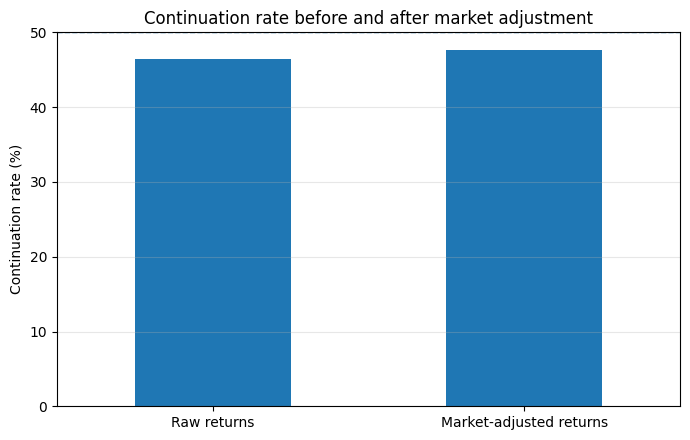

In [52]:
continuation_comparison = pd.Series(
    {
        "Raw returns": raw_continuation_rate * 100,
        "Market-adjusted returns": adjusted_continuation_rate * 100,
    }
)

fig, ax = plt.subplots(figsize=(7, 4.5))
continuation_comparison.plot(kind="bar", ax=ax)
ax.axhline(50, linestyle="--", linewidth=1)
ax.set_title("Continuation rate before and after market adjustment")
ax.set_xlabel("")
ax.set_ylabel("Continuation rate (%)")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 7. Sector-specific analysis

The analysis below tests whether extreme-opening continuation and reversal vary across sectors.

Sector statistics are calculated only from events already classified as extreme by the daily
cross-sectional top-20% rule. The analysis reports event counts, continuation and reversal rates,
direction-adjusted rest-of-day returns, and uncertainty estimates. It also examines whether the
aggregate effect survives removal of the median movement within each sector.


In [53]:
# Align the instrument metadata with the symbols used by yfinance.
instrument_metadata = snp500_instruments[
    ["symbol", "sector", "industry"]
].copy()

instrument_metadata["download_symbol"] = instrument_metadata["symbol"].map(
    lambda symbol: symbol_map.get(symbol, symbol)
)

instrument_metadata["sector"] = (
    instrument_metadata["sector"]
    .fillna("Unknown")
    .replace("", "Unknown")
)

# Each downloaded symbol should map to a single sector.
sector_conflicts = (
    instrument_metadata.groupby("download_symbol")["sector"]
    .nunique()
)

assert not sector_conflicts.gt(1).any(), (
    "At least one downloaded symbol maps to multiple sectors."
)

sector_lookup = (
    instrument_metadata
    .drop_duplicates("download_symbol")
    .set_index("download_symbol")["sector"]
)

industry_lookup = (
    instrument_metadata
    .drop_duplicates("download_symbol")
    .set_index("download_symbol")["industry"]
)

metadata_coverage = pd.DataFrame(
    {
        "symbol": successful_symbols,
        "sector": pd.Series(successful_symbols).map(sector_lookup),
        "industry": pd.Series(successful_symbols).map(industry_lookup),
    }
)

print(
    "Symbols with sector metadata:",
    int(metadata_coverage["sector"].notna().sum()),
    "/",
    len(metadata_coverage),
)

display(
    metadata_coverage[
        metadata_coverage["sector"].isna()
    ].head(30)
)


Symbols with sector metadata: 516 / 516


,symbol,sector,industry


In [54]:
# Build one row per extreme-opening stock-day.
sector_event_data = pd.concat(
    [
        opening_return.where(valid_strong_event)
        .stack()
        .rename("opening_return"),
        post_opening_return.where(valid_strong_event)
        .stack()
        .rename("post_opening_return"),
        directional_post_return
        .stack()
        .rename("persistence_return"),
        strong_continuation
        .stack()
        .rename("continuation"),
        pattern_with_flat.where(valid_strong_event)
        .stack()
        .rename("pattern"),
    ],
    axis=1,
).dropna(
    subset=[
        "opening_return",
        "post_opening_return",
        "persistence_return",
        "continuation",
    ]
).reset_index()

sector_event_data["sector"] = (
    sector_event_data["symbol"].map(sector_lookup)
)

sector_event_data["industry"] = (
    sector_event_data["symbol"].map(industry_lookup)
)

sector_event_data = sector_event_data.dropna(
    subset=["sector"]
).copy()

sector_event_data["opening_direction"] = np.where(
    sector_event_data["opening_return"].gt(0),
    "Positive opening",
    np.where(
        sector_event_data["opening_return"].lt(0),
        "Negative opening",
        "Flat opening",
    ),
)

sector_summary = (
    sector_event_data.groupby("sector")
    .agg(
        event_count=("symbol", "size"),
        distinct_symbols=("symbol", "nunique"),
        trading_dates=("date", "nunique"),
        continuation_rate=("continuation", "mean"),
        mean_persistence_return=("persistence_return", "mean"),
        median_persistence_return=("persistence_return", "median"),
        persistence_std=("persistence_return", "std"),
        mean_absolute_opening_return=(
            "opening_return",
            lambda values: values.abs().mean(),
        ),
        mean_absolute_post_opening_return=(
            "post_opening_return",
            lambda values: values.abs().mean(),
        ),
    )
)

sector_summary["reversal_rate"] = (
    1 - sector_summary["continuation_rate"]
)

# Force the aggregated columns to regular numeric dtypes.
# Some stacked boolean/object columns can otherwise leave the result as
# dtype=object, which causes NumPy ufuncs such as sqrt() to fail.
numeric_summary_columns = [
    "event_count",
    "distinct_symbols",
    "trading_dates",
    "continuation_rate",
    "reversal_rate",
    "mean_persistence_return",
    "median_persistence_return",
    "persistence_std",
    "mean_absolute_opening_return",
    "mean_absolute_post_opening_return",
]

for column in numeric_summary_columns:
    sector_summary[column] = pd.to_numeric(
        sector_summary[column],
        errors="coerce",
    )

continuation_rate_values = sector_summary[
    "continuation_rate"
].to_numpy(dtype=float)

event_count_values = sector_summary[
    "event_count"
].to_numpy(dtype=float)

sector_summary["continuation_se"] = np.sqrt(
    continuation_rate_values
    * (1.0 - continuation_rate_values)
    / event_count_values
)

persistence_std_values = sector_summary[
    "persistence_std"
].to_numpy(dtype=float)

sector_summary["persistence_se"] = (
    persistence_std_values
    / np.sqrt(event_count_values)
)

direction_rates = (
    sector_event_data[
        sector_event_data["opening_direction"].isin(
            ["Positive opening", "Negative opening"]
        )
    ]
    .groupby(["sector", "opening_direction"])["continuation"]
    .mean()
    .unstack()
    .rename(
        columns={
            "Positive opening": "positive_open_continuation_rate",
            "Negative opening": "negative_open_continuation_rate",
        }
    )
)

sector_summary = (
    sector_summary
    .join(direction_rates)
    .sort_values("event_count", ascending=False)
)

display(
    sector_summary.style.format(
        {
            "event_count": "{:,.0f}",
            "distinct_symbols": "{:,.0f}",
            "trading_dates": "{:,.0f}",
            "continuation_rate": "{:.2%}",
            "reversal_rate": "{:.2%}",
            "positive_open_continuation_rate": "{:.2%}",
            "negative_open_continuation_rate": "{:.2%}",
            "mean_persistence_return": "{:.3%}",
            "median_persistence_return": "{:.3%}",
            "persistence_std": "{:.3%}",
            "continuation_se": "{:.3%}",
            "persistence_se": "{:.3%}",
            "mean_absolute_opening_return": "{:.3%}",
            "mean_absolute_post_opening_return": "{:.3%}",
        }
    )
)


,event_count,distinct_symbols,trading_dates,continuation_rate,mean_persistence_return,median_persistence_return,persistence_std,mean_absolute_opening_return,mean_absolute_post_opening_return,reversal_rate,continuation_se,persistence_se,negative_open_continuation_rate,positive_open_continuation_rate
sector,,,,,,,,,,,,,,
Technology,"1,012",65,37,44.37%,-0.325%,-0.303%,2.920%,2.783%,2.227%,55.63%,1.562%,0.092%,42.52%,46.23%
"Consumer, Non-cyclical",705,105,37,45.96%,-0.125%,-0.122%,1.599%,2.165%,1.173%,54.04%,1.877%,0.060%,45.14%,46.63%
Communications,484,43,37,47.11%,-0.246%,-0.130%,2.531%,2.699%,1.930%,52.89%,2.269%,0.115%,42.48%,51.16%
Industrial,474,73,37,50.42%,-0.128%,0.016%,1.978%,2.356%,1.421%,49.58%,2.296%,0.091%,51.71%,49.17%
"Consumer, Cyclical",436,56,37,49.77%,0.027%,-0.012%,1.986%,2.340%,1.422%,50.23%,2.395%,0.095%,49.71%,49.81%
Financial,358,86,37,43.30%,-0.271%,-0.263%,1.709%,2.134%,1.304%,56.70%,2.619%,0.090%,45.70%,41.55%
Energy,156,21,34,45.51%,-0.115%,-0.183%,1.775%,2.114%,1.378%,54.49%,3.987%,0.142%,59.38%,35.87%
Basic Materials,139,18,36,46.04%,-0.066%,-0.164%,2.068%,2.240%,1.555%,53.96%,4.228%,0.175%,51.39%,40.30%
Utilities,63,18,27,50.79%,0.120%,0.090%,1.297%,2.192%,1.027%,49.21%,6.299%,0.163%,51.61%,50.00%


### 7.1 Continuation rate by sector

The dashed 50% line separates sectors with more continuation than reversal from sectors with more
reversal than continuation. Error bars show approximate 95% normal confidence intervals for the
sector continuation proportion. These intervals are descriptive because observations on the same
date are cross-sectionally correlated.


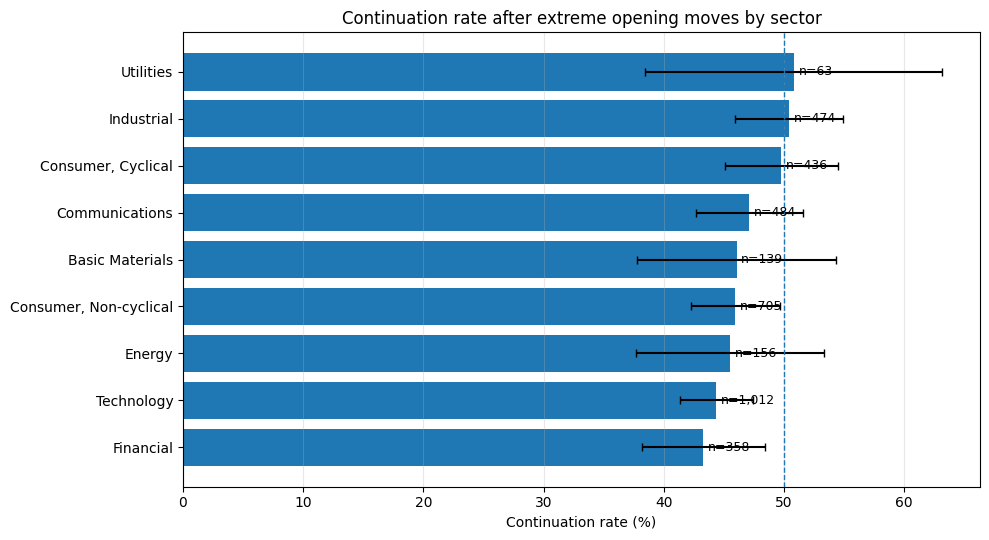

In [55]:
minimum_sector_events = 30

sector_rate_plot = (
    sector_summary[
        sector_summary["event_count"] >= minimum_sector_events
    ]
    .sort_values("continuation_rate")
)

continuation_pct = (
    sector_rate_plot["continuation_rate"].mul(100)
)

continuation_error_pct = (
    1.96 * sector_rate_plot["continuation_se"].mul(100)
)

fig, ax = plt.subplots(
    figsize=(10, max(5.5, 0.48 * len(sector_rate_plot)))
)

ax.barh(
    sector_rate_plot.index,
    continuation_pct,
    xerr=continuation_error_pct,
    capsize=3,
)

ax.axvline(50, linestyle="--", linewidth=1)
ax.set_title("Continuation rate after extreme opening moves by sector")
ax.set_xlabel("Continuation rate (%)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)

for position, (sector, row) in enumerate(
    sector_rate_plot.iterrows()
):
    ax.text(
        continuation_pct.loc[sector] + 0.4,
        position,
        f"n={int(row['event_count']):,}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


### 7.2 Direction-adjusted rest-of-day return by sector

A negative persistence return indicates average reversal after the extreme opening move. A positive
value indicates continuation. Error bars show approximately 95% confidence intervals around the
sector mean, without adjustment for same-day cross-sectional dependence.


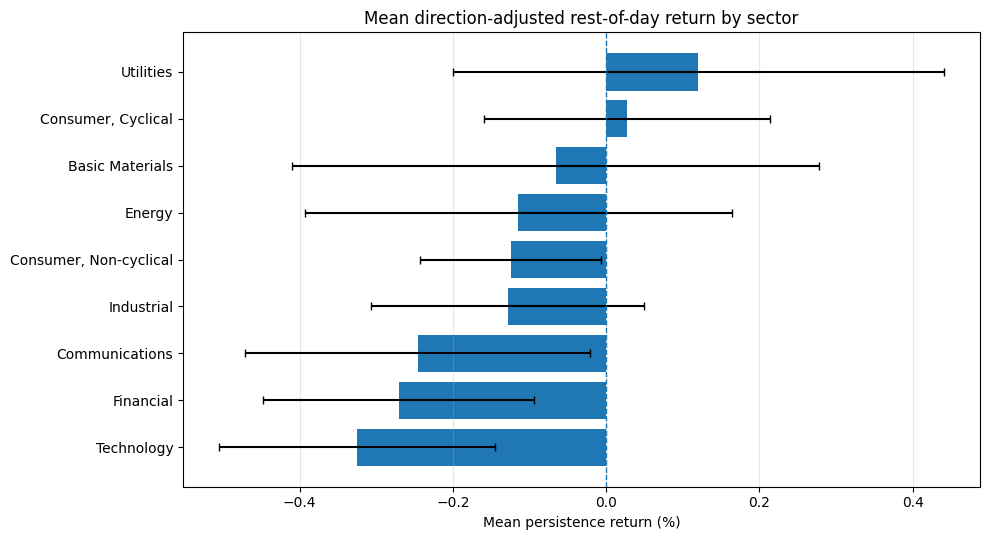

In [56]:
sector_persistence_plot = (
    sector_summary[
        sector_summary["event_count"] >= minimum_sector_events
    ]
    .sort_values("mean_persistence_return")
)

mean_persistence_pct = (
    sector_persistence_plot["mean_persistence_return"].mul(100)
)

persistence_error_pct = (
    1.96 * sector_persistence_plot["persistence_se"].mul(100)
)

fig, ax = plt.subplots(
    figsize=(10, max(5.5, 0.48 * len(sector_persistence_plot)))
)

ax.barh(
    sector_persistence_plot.index,
    mean_persistence_pct,
    xerr=persistence_error_pct,
    capsize=3,
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title(
    "Mean direction-adjusted rest-of-day return by sector"
)
ax.set_xlabel("Mean persistence return (%)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


### 7.3 Directional outcome composition by sector

This chart decomposes each sector's extreme-opening observations into up continuation, up reversal,
down continuation, down reversal, and flat outcomes.


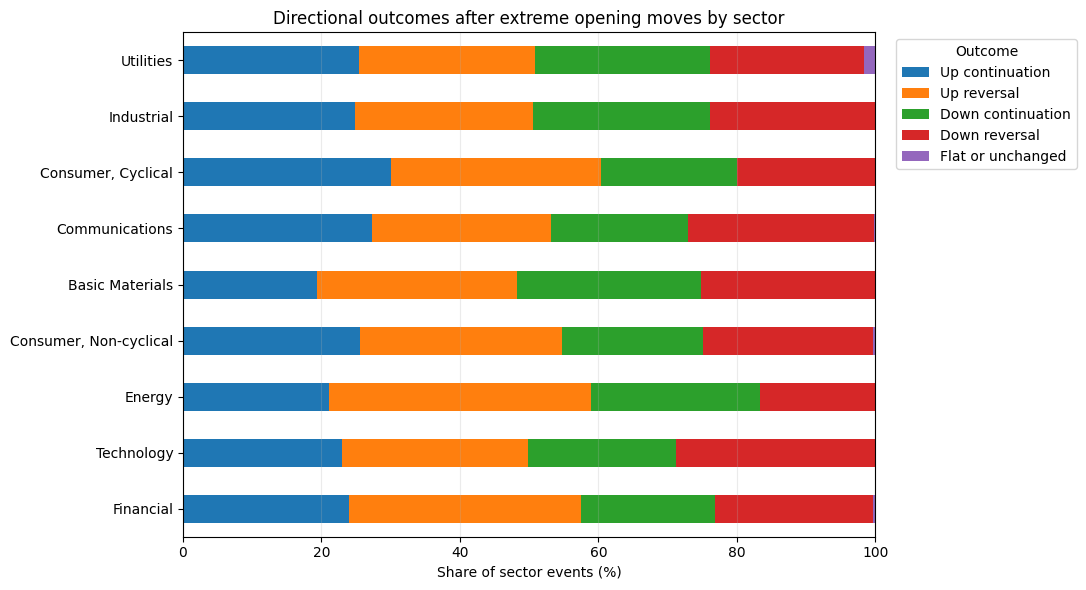

In [57]:
pattern_order = [
    "Up continuation",
    "Up reversal",
    "Down continuation",
    "Down reversal",
    "Flat or unchanged",
]

sector_pattern_share = pd.crosstab(
    sector_event_data["sector"],
    sector_event_data["pattern"],
    normalize="index",
).reindex(
    columns=pattern_order,
    fill_value=0,
)

sector_pattern_share = (
    sector_pattern_share
    .loc[sector_rate_plot.index]
    .mul(100)
)

fig, ax = plt.subplots(
    figsize=(11, max(6, 0.52 * len(sector_pattern_share)))
)

sector_pattern_share.plot(
    kind="barh",
    stacked=True,
    ax=ax,
)

ax.set_title("Directional outcomes after extreme opening moves by sector")
ax.set_xlabel("Share of sector events (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.25)
ax.legend(
    title="Outcome",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


### 7.4 Sector-adjusted continuation and reversal

The market-adjusted analysis removes the median move across all stocks on each date. The
sector-adjusted analysis instead removes the median move within each date-sector group. This helps
test whether the effect reflects stock-specific movement relative to sector peers.


In [58]:
# Construct a complete long-form intraday return table before filtering
# to extreme events, so date-sector medians are calculated from all
# available stocks in the sector.
all_intraday_long = pd.concat(
    [
        opening_return.stack().rename("opening_return"),
        post_opening_return.stack().rename("post_opening_return"),
    ],
    axis=1,
).dropna().reset_index()

all_intraday_long["sector"] = (
    all_intraday_long["symbol"].map(sector_lookup)
)

strong_event_long = (
    valid_strong_event
    .stack()
    .rename("is_strong_event")
    .reset_index()
)

all_intraday_long = all_intraday_long.merge(
    strong_event_long,
    on=["date", "symbol"],
    how="left",
)

all_intraday_long["is_strong_event"] = (
    all_intraday_long["is_strong_event"]
    .fillna(False)
    .astype(bool)
)

all_intraday_long = all_intraday_long.dropna(
    subset=["sector"]
).copy()

all_intraday_long["sector_opening_median"] = (
    all_intraday_long.groupby(
        ["date", "sector"]
    )["opening_return"].transform("median")
)

all_intraday_long["sector_post_opening_median"] = (
    all_intraday_long.groupby(
        ["date", "sector"]
    )["post_opening_return"].transform("median")
)

all_intraday_long["sector_opening_excess"] = (
    all_intraday_long["opening_return"]
    - all_intraday_long["sector_opening_median"]
)

all_intraday_long["sector_post_opening_excess"] = (
    all_intraday_long["post_opening_return"]
    - all_intraday_long["sector_post_opening_median"]
)

sector_adjusted_events = all_intraday_long[
    all_intraday_long["is_strong_event"]
].copy()

sector_adjusted_events["sector_adjusted_continuation"] = (
    np.sign(sector_adjusted_events["sector_opening_excess"])
    == np.sign(sector_adjusted_events["sector_post_opening_excess"])
)

sector_adjusted_events["sector_adjusted_persistence_return"] = (
    np.sign(sector_adjusted_events["sector_opening_excess"])
    * sector_adjusted_events["sector_post_opening_excess"]
)

sector_adjusted_continuation_rate = (
    sector_adjusted_events["sector_adjusted_continuation"].mean()
)

sector_adjusted_mean_persistence = (
    sector_adjusted_events["sector_adjusted_persistence_return"].mean()
)

adjustment_summary = pd.DataFrame(
    {
        "continuation_rate": [
            raw_continuation_rate,
            adjusted_continuation_rate,
            sector_adjusted_continuation_rate,
        ],
        "mean_persistence_return": [
            raw_mean_persistence,
            adjusted_mean_persistence,
            sector_adjusted_mean_persistence,
        ],
    },
    index=[
        "Raw returns",
        "Market-adjusted returns",
        "Sector-adjusted returns",
    ],
)

display(
    adjustment_summary.style.format(
        {
            "continuation_rate": "{:.2%}",
            "mean_persistence_return": "{:.3%}",
        }
    )
)


,continuation_rate,mean_persistence_return
Raw returns,46.49%,-0.183%
Market-adjusted returns,47.64%,-0.114%
Sector-adjusted returns,48.52%,-0.107%


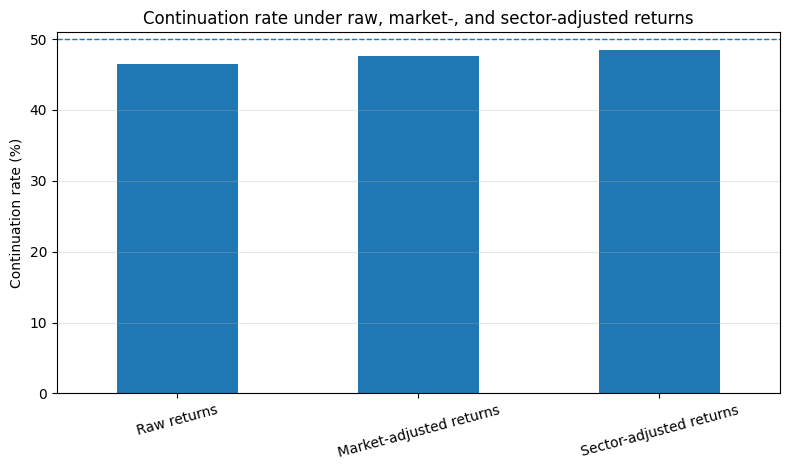

In [59]:
adjustment_continuation_chart = (
    adjustment_summary["continuation_rate"].mul(100)
)

fig, ax = plt.subplots(figsize=(8, 4.8))
adjustment_continuation_chart.plot(kind="bar", ax=ax)

ax.axhline(50, linestyle="--", linewidth=1)
ax.set_title(
    "Continuation rate under raw, market-, and sector-adjusted returns"
)
ax.set_xlabel("")
ax.set_ylabel("Continuation rate (%)")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


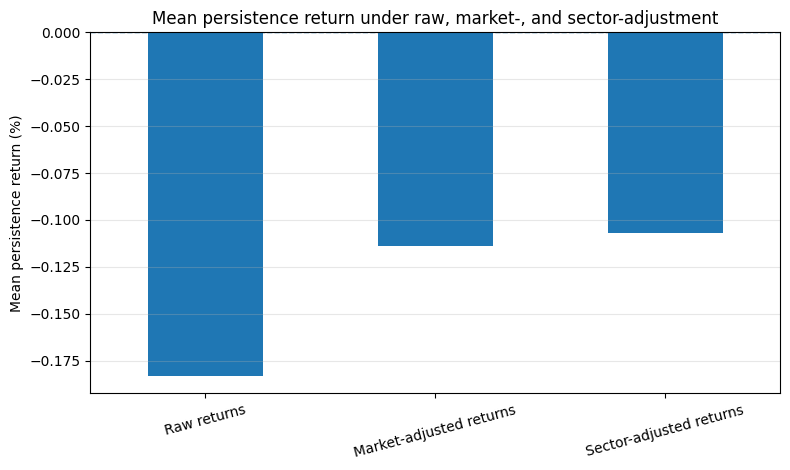

In [60]:
adjustment_persistence_chart = (
    adjustment_summary["mean_persistence_return"].mul(100)
)

fig, ax = plt.subplots(figsize=(8, 4.8))
adjustment_persistence_chart.plot(kind="bar", ax=ax)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title(
    "Mean persistence return under raw, market-, and sector-adjustment"
)
ax.set_xlabel("")
ax.set_ylabel("Mean persistence return (%)")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


### 7.5 Opening-move magnitude and persistence within sectors

The heatmap shows mean direction-adjusted rest-of-day return for each sector and daily
opening-magnitude quintile. Q5 contains the largest absolute opening moves. Cells with fewer than
20 observations are suppressed to avoid interpreting very small samples.


In [61]:
sector_quintile_data = (
    quintile_data
    .reset_index()
)

sector_quintile_data["sector"] = (
    sector_quintile_data["symbol"].map(sector_lookup)
)

sector_quintile_data = sector_quintile_data.dropna(
    subset=["sector"]
)

sector_quintile_mean = (
    sector_quintile_data
    .groupby(["sector", "quintile"])["persistence_return"]
    .mean()
    .unstack()
    .reindex(columns=[1, 2, 3, 4, 5])
)

sector_quintile_count = (
    sector_quintile_data
    .groupby(["sector", "quintile"])["persistence_return"]
    .size()
    .unstack()
    .reindex(columns=[1, 2, 3, 4, 5])
)

minimum_heatmap_events = 20

sector_quintile_mean_filtered = (
    sector_quintile_mean.where(
        sector_quintile_count >= minimum_heatmap_events
    )
)

sector_quintile_mean_filtered = (
    sector_quintile_mean_filtered
    .loc[
        sector_summary.sort_values(
            "mean_persistence_return"
        ).index
    ]
)

display(
    sector_quintile_mean_filtered.style.format("{:.3%}")
)


quintile,1,2,3,4,5
sector,,,,,
Technology,-0.281%,-0.162%,-0.085%,-0.273%,-0.325%
Financial,0.037%,0.021%,-0.105%,-0.190%,-0.271%
Communications,-0.006%,0.147%,-0.095%,-0.106%,-0.246%
Industrial,0.078%,0.038%,-0.033%,-0.073%,-0.128%
"Consumer, Non-cyclical",-0.025%,-0.089%,-0.166%,-0.059%,-0.125%
Energy,-0.118%,-0.055%,0.065%,-0.116%,-0.115%
Basic Materials,0.129%,-0.158%,-0.313%,-0.206%,-0.066%
"Consumer, Cyclical",-0.044%,-0.087%,-0.234%,-0.016%,0.027%
Utilities,-0.066%,0.087%,0.058%,-0.178%,0.120%


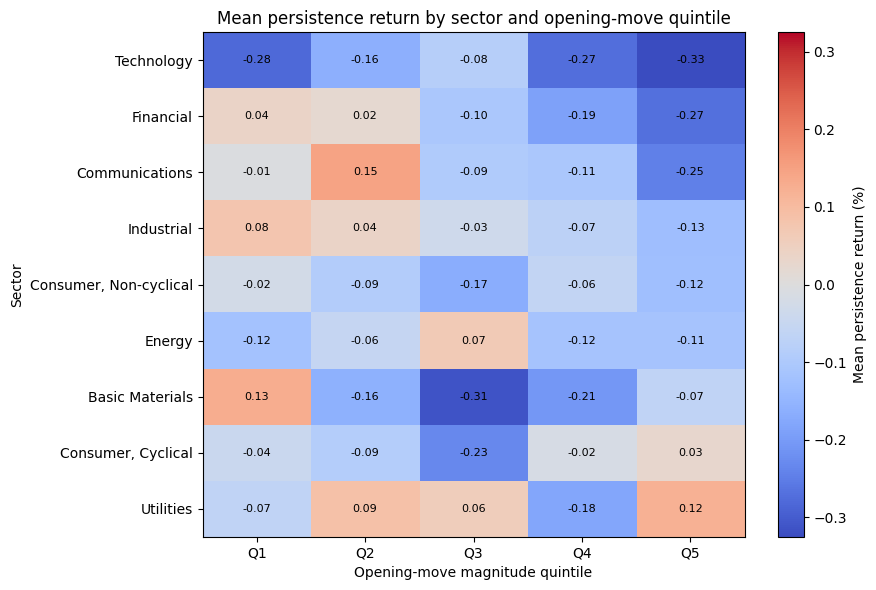

In [62]:
heatmap_values = (
    sector_quintile_mean_filtered.mul(100)
)

finite_values = heatmap_values.to_numpy()
finite_values = finite_values[np.isfinite(finite_values)]

heatmap_limit = (
    np.nanmax(np.abs(finite_values))
    if finite_values.size
    else 1.0
)

fig, ax = plt.subplots(
    figsize=(9, max(6, 0.48 * len(heatmap_values)))
)

image = ax.imshow(
    heatmap_values.to_numpy(),
    aspect="auto",
    cmap="coolwarm",
    vmin=-heatmap_limit,
    vmax=heatmap_limit,
)

ax.set_title(
    "Mean persistence return by sector and opening-move quintile"
)
ax.set_xlabel("Opening-move magnitude quintile")
ax.set_ylabel("Sector")
ax.set_xticks(range(5))
ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4", "Q5"])
ax.set_yticks(range(len(heatmap_values.index)))
ax.set_yticklabels(heatmap_values.index)

for row_number in range(heatmap_values.shape[0]):
    for column_number in range(heatmap_values.shape[1]):
        value = heatmap_values.iat[row_number, column_number]
        if np.isfinite(value):
            ax.text(
                column_number,
                row_number,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Mean persistence return (%)")

plt.tight_layout()
plt.show()


### Sector-analysis interpretation checklist

When interpreting sector differences, check:

- whether sectors with lower continuation rates also have more negative persistence returns;
- whether positive and negative opening moves behave similarly within each sector;
- whether apparent sector differences remain after accounting for event counts and confidence intervals;
- whether Q5 is more reversal-prone than weaker opening-move quintiles within most sectors;
- whether the aggregate result survives sector demeaning;
- whether a small number of symbols or dates dominates a sector's result.

The current intraday window is short. Sector findings should therefore be treated as exploratory
and validated on a longer, chronologically out-of-sample dataset.


# Interpretation checklist

When reviewing the charts, focus on:

- which trading-day segment contained the largest typical absolute movement;
- whether continuation rates were consistently below or above 50% across dates;
- whether positive and negative opening moves behaved symmetrically;
- whether the scatter relationship was broadly downward or upward;
- whether persistence changed monotonically across opening-move quintiles;
- whether the result survived cross-sectional market adjustment.

Because the data cover a short recent window and stocks on the same date are correlated, the results should be treated as **regime-specific exploratory evidence**, not as a stable trading rule.

Additional sector checks:

- compare continuation and persistence across sectors rather than relying only on the aggregate;
- inspect whether confidence intervals overlap before claiming meaningful sector differences;
- compare raw, market-adjusted, and sector-adjusted effects;
- verify that the strongest sector result is not driven by a few symbols or dates.
